# Avazu Click-Through Rate Prediction
## Proyecto de Deep Learning — Redes Neuronales con scikit-learn y PySpark

**Dataset:** Avazu CTR Prediction (Kaggle)  
**Objetivo:** Predecir si un usuario hará clic en un anuncio móvil (clasificación binaria)  
**Modelos:** MLPClassifier (scikit-learn) + MultilayerPerceptronClassifier (PySpark)  
**Interpretabilidad:** LIME

---

## 0. Instalación de dependencias

In [1]:
# Instalar librerías necesarias (ejecutar una vez)
!pip install lime category_encoders pyspark findspark --quiet

## 📚 1. Importaciones Generales

In [2]:
# ── Librerías estándar ──────────────────────────────────────────────────────
import time, warnings, sys
warnings.filterwarnings('ignore')

# ── Manipulación de datos ───────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── scikit-learn ────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve
)
from category_encoders import TargetEncoder

# ── LIME ────────────────────────────────────────────────────────────────────
import lime
import lime.lime_tabular

# ── Utilidad: decorador para medir tiempo de celda ─────────────────────────
def _cell_timer(label):
    """Imprime el tiempo transcurrido al final de cada celda."""
    class _T:
        def __init__(self): self.t0 = time.time()
        def stop(self):
            elapsed = time.time() - self.t0
            mins, secs = divmod(elapsed, 60)
            tag = f'{int(mins)}m {secs:.1f}s' if mins else f'{secs:.2f}s'
            print(f'\n⏱️  [{label}] completado en {tag}')
    return _T()

# Configuración de visualización
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('✅ Librerías importadas correctamente')


✅ Librerías importadas correctamente


---
## 📊 2. Carga y Exploración de Datos (EDA)

In [3]:
_t = _cell_timer('Carga EDA')

DATASET_PATH = 'avazu-ctr-prediction/train.gz'  # Ajusta si es necesario

print('📂 Cargando muestra de 500K filas para EDA...')
df = pd.read_csv(DATASET_PATH, nrows=500_000, dtype={'id': str})
print(f'✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

# ── Información general
print('\n=== Tipos de datos y valores no nulos ===')
df.info()

# ── Valores faltantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje (%)': missing_pct})
missing_df = missing_df[missing_df['Faltantes'] > 0]
if missing_df.empty:
    print('\n✅ No hay valores faltantes.')
else:
    print('\n⚠️  Valores faltantes:')
    print(missing_df)

# ── Cardinalidad
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
card = df[cat_cols].nunique().sort_values(ascending=False)
print('\n=== Cardinalidad de variables categóricas ===')
print(card.to_string())

# ── Features temporales
print('\n🔧 Creando features temporales...')
df['hour'] = df['hour'].astype(str)
df['hour_of_day']  = df['hour'].str[-2:].astype(int)
df['day_of_month'] = df['hour'].str[4:6].astype(int)
df['day_of_week']  = pd.to_datetime('20' + df['hour'].str[:6], format='%Y%m%d').dt.dayofweek

def franja_horaria(h):
    if 6 <= h < 12:   return 'Mañana'
    elif 12 <= h < 18: return 'Tarde'
    elif 18 <= h < 24: return 'Noche'
    else:              return 'Madrugada'

df['franja'] = df['hour_of_day'].apply(franja_horaria)
print('✅ Variables temporales: hour_of_day, day_of_month, day_of_week, franja')
print(f'\n=== Estadísticas descriptivas ===')
display(df.describe(include='all').T)

_t.stop()


📂 Cargando muestra de 500K filas para EDA...
✅ Dataset cargado: 500,000 filas × 24 columnas

=== Tipos de datos y valores no nulos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                500000 non-null  object
 1   click             500000 non-null  int64 
 2   hour              500000 non-null  int64 
 3   C1                500000 non-null  int64 
 4   banner_pos        500000 non-null  int64 
 5   site_id           500000 non-null  object
 6   site_domain       500000 non-null  object
 7   site_category     500000 non-null  object
 8   app_id            500000 non-null  object
 9   app_domain        500000 non-null  object
 10  app_category      500000 non-null  object
 11  device_id         500000 non-null  object
 12  device_ip         500000 non-null  object
 13  device_model      500000 non-null  object
 1

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,500000,500000,1000009418151094273,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
click,500000.0,NaN,NaN,NaN,0.164074,0.370343,0.0,0.0,0.0,0.0,1.0
hour,500000,4,14102102,207471,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C1,500000.0,NaN,NaN,NaN,1005.034018,0.966678,1001.0,1005.0,1005.0,1005.0,1012.0
banner_pos,500000.0,NaN,NaN,NaN,0.217276,0.443134,0.0,0.0,0.0,0.0,7.0
site_id,500000,1704,85f751fd,153042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
site_domain,500000,1586,c4e18dd6,158738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
site_category,500000,21,50e219e0,166816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
app_id,500000,1641,ecad2386,346958,NaN,NaN,NaN,NaN,NaN,NaN,NaN
app_domain,500000,122,7801e8d9,366566,NaN,NaN,NaN,NaN,NaN,NaN,NaN



⏱️  [Carga EDA] completado en 6.52s


### 📈 2.1 Visualizaciones EDA

📊 Generando gráficos EDA...
  → 1/5 Distribución de la variable click...


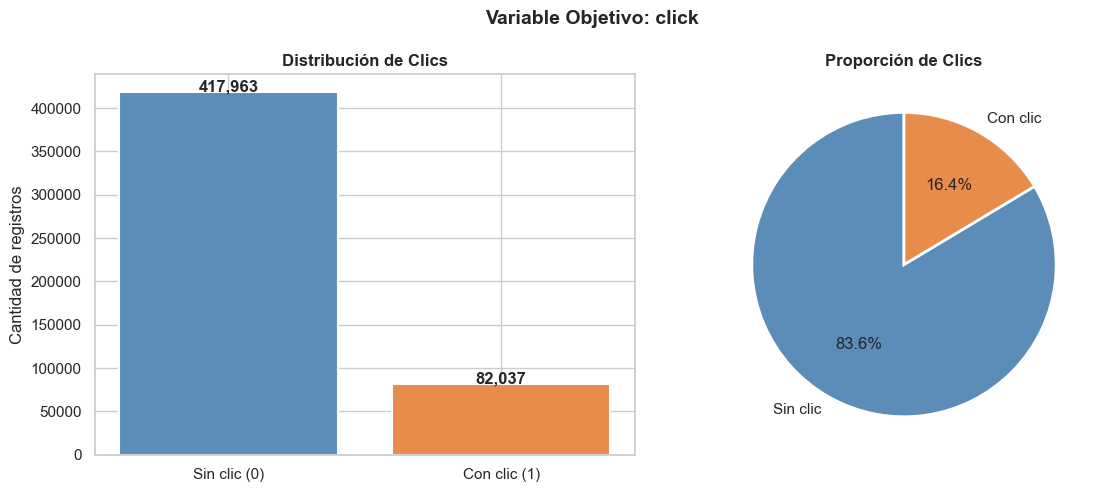

  → 2/5 Distribución de clics por hora...


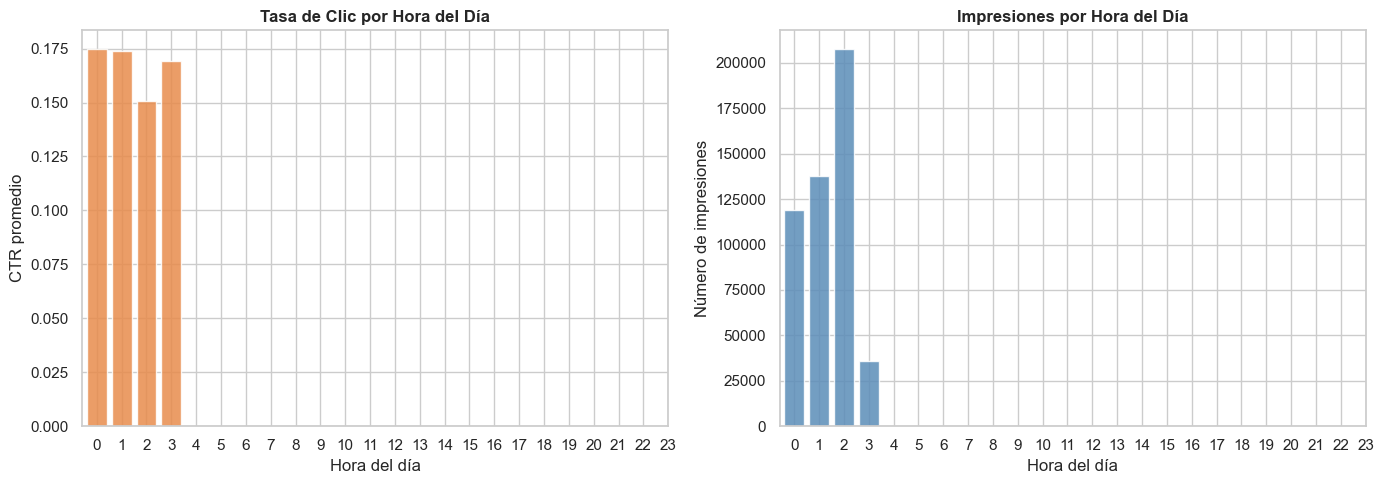

  → 3/5 Histogramas variables temporales...


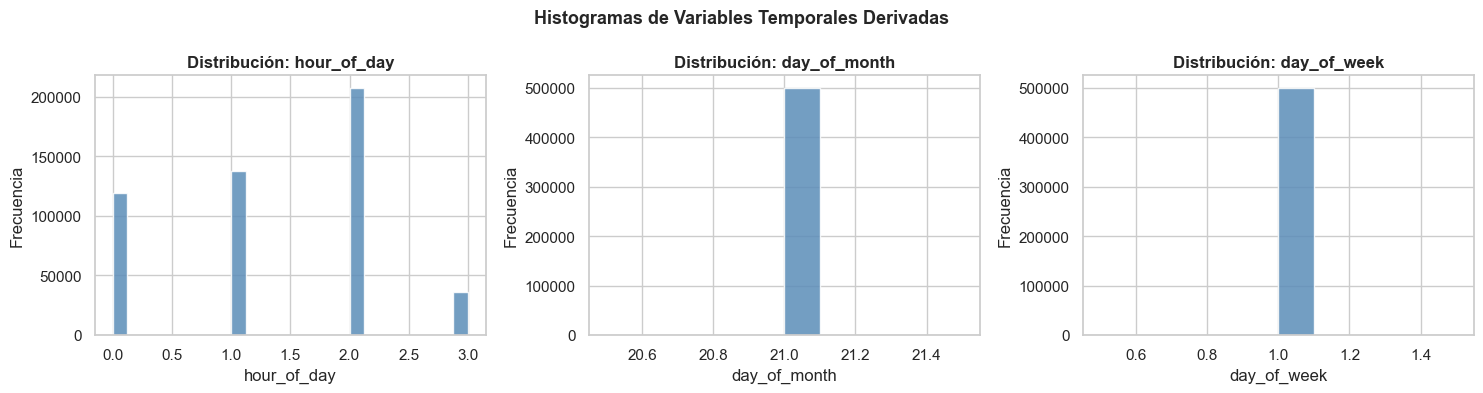

  → 4/5 Frecuencia de variables categóricas...


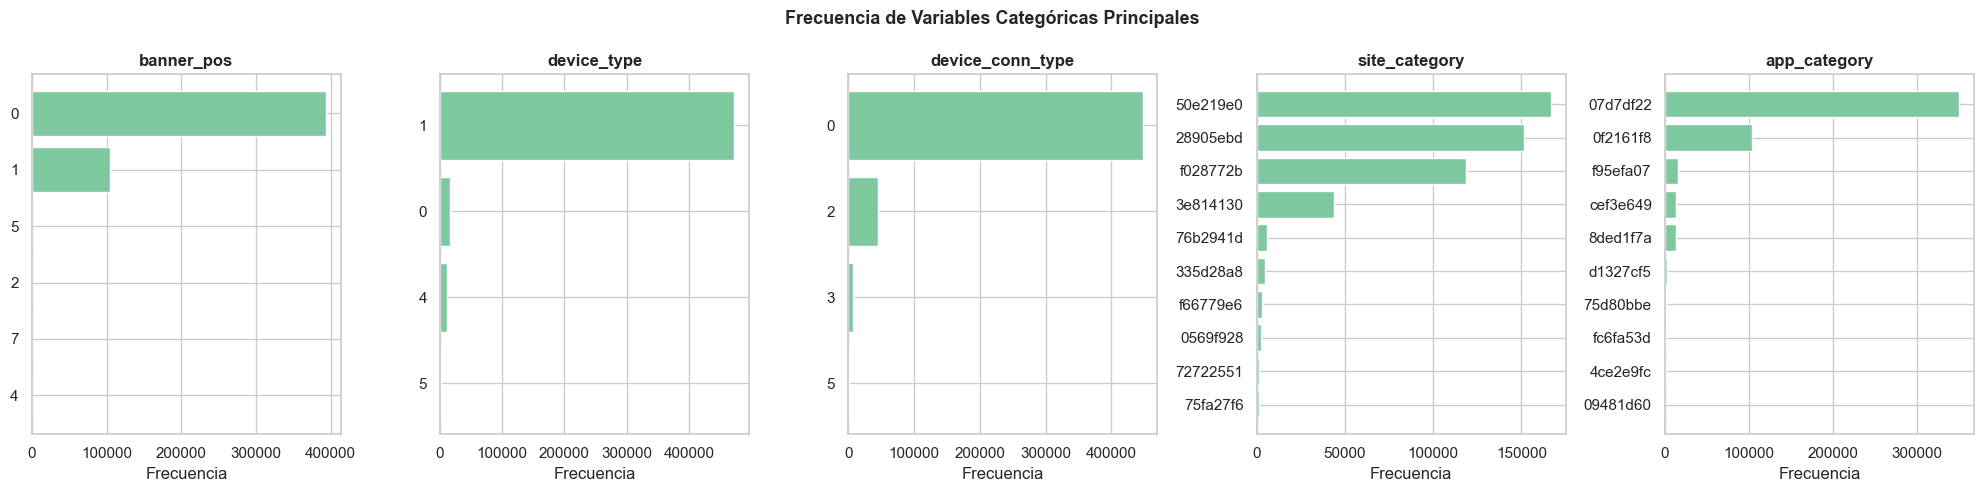

  → 5/5 Matriz de correlación...


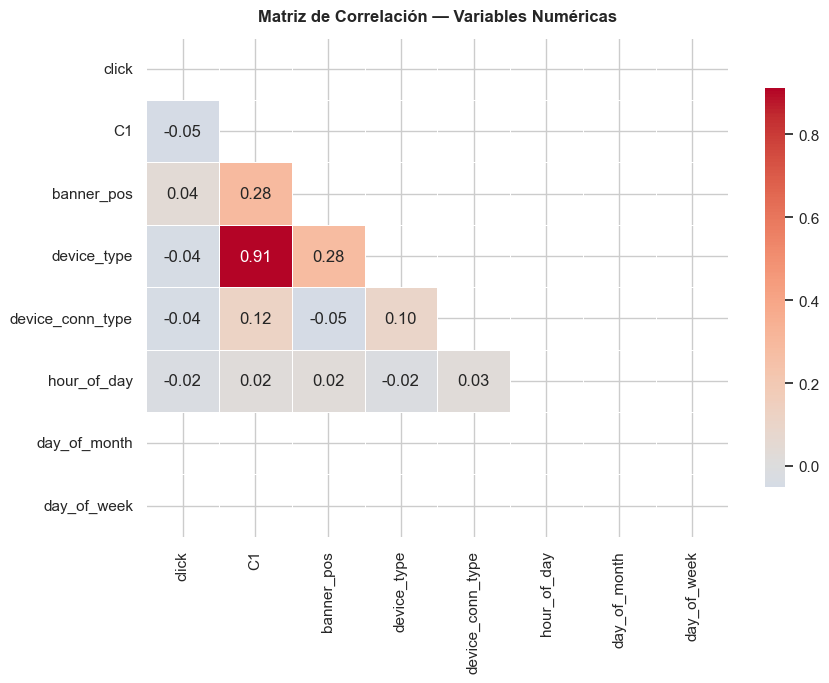


✅ Todos los gráficos EDA generados.

⏱️  [Visualizaciones EDA] completado en 5.72s


In [4]:
_t = _cell_timer('Visualizaciones EDA')
print('📊 Generando gráficos EDA...')

# ── Gráfico 1: Distribución click
print('  → 1/5 Distribución de la variable click...')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
click_counts = df['click'].value_counts()
axes[0].bar(['Sin clic (0)', 'Con clic (1)'], click_counts.values,
            color=['#5B8DB8', '#E88C4C'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de Clics', fontweight='bold')
axes[0].set_ylabel('Cantidad de registros')
for i, v in enumerate(click_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')
axes[1].pie(click_counts.values, labels=['Sin clic', 'Con clic'],
            autopct='%1.1f%%', colors=['#5B8DB8', '#E88C4C'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Clics', fontweight='bold')
plt.suptitle('Variable Objetivo: click', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_click_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Gráfico 2: CTR por hora
print('  → 2/5 Distribución de clics por hora...')
ctr_por_hora   = df.groupby('hour_of_day')['click'].mean().reset_index()
count_por_hora = df.groupby('hour_of_day')['click'].count().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(ctr_por_hora['hour_of_day'], ctr_por_hora['click'], color='#E88C4C', alpha=0.85)
axes[0].set_xlabel('Hora del día'); axes[0].set_ylabel('CTR promedio')
axes[0].set_title('Tasa de Clic por Hora del Día', fontweight='bold')
axes[0].set_xticks(range(0, 24))
axes[1].bar(count_por_hora['hour_of_day'], count_por_hora['click'], color='#5B8DB8', alpha=0.85)
axes[1].set_xlabel('Hora del día'); axes[1].set_ylabel('Número de impresiones')
axes[1].set_title('Impresiones por Hora del Día', fontweight='bold')
axes[1].set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig('fig_ctr_por_hora.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Gráfico 3: Histogramas
print('  → 3/5 Histogramas variables temporales...')
num_vars = ['hour_of_day', 'day_of_month', 'day_of_week']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_vars):
    ax.hist(df[col], bins=24 if col == 'hour_of_day' else 10,
            color='#5B8DB8', edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribución: {col}', fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Frecuencia')
plt.suptitle('Histogramas de Variables Temporales Derivadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_histogramas_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Gráfico 4: Frecuencia categóricas
print('  → 4/5 Frecuencia de variables categóricas...')
top_cats = ['banner_pos', 'device_type', 'device_conn_type', 'site_category', 'app_category']
fig, axes = plt.subplots(1, len(top_cats), figsize=(20, 5))
for ax, col in zip(axes, top_cats):
    top_vals = df[col].value_counts().head(10)
    ax.barh(top_vals.index.astype(str), top_vals.values, color='#7EC8A0', edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Frecuencia')
    ax.invert_yaxis()
plt.suptitle('Frecuencia de Variables Categóricas Principales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_categoricas_frecuencia.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Gráfico 5: Correlación
print('  → 5/5 Matriz de correlación...')
num_cols = ['click', 'C1', 'banner_pos', 'device_type',
            'device_conn_type', 'hour_of_day', 'day_of_month', 'day_of_week']
corr_df = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlación — Variables Numéricas', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Todos los gráficos EDA generados.')
_t.stop()


---
## 🔧 3. Preprocesamiento con scikit-learn

Debido al tamaño del dataset (~40M filas), se usa **chunk sampling** para obtener ~1M de registros sin cargar todo en RAM.

In [5]:
_t = _cell_timer('Preprocesamiento sklearn')

SAMPLE_FRACTION = 0.025    # 2.5% de 40M ≈ 1M filas
CHUNK_SIZE      = 200_000  # Máximo ~500MB RAM en un momento
RANDOM_SEED     = 42

sampled_chunks = []
total_seen     = 0

print('📂 Leyendo y muestreando el dataset completo por chunks...')
print(f'   Fracción de muestra: {SAMPLE_FRACTION*100:.1f}%  |  Chunk size: {CHUNK_SIZE:,}')

for i, chunk in enumerate(pd.read_csv(DATASET_PATH, dtype={'id': str}, chunksize=CHUNK_SIZE)):
    sampled_chunks.append(chunk.sample(frac=SAMPLE_FRACTION, random_state=RANDOM_SEED))
    total_seen += len(chunk)
    chunks_done = i + 1
    if chunks_done % 20 == 0 or total_seen >= 40_000_000:
        pct = min(total_seen / 40_500_000 * 100, 100)
        bar = '█' * int(pct // 5) + '░' * (20 - int(pct // 5))
        print(f'  [{bar}] {pct:5.1f}%  —  {total_seen:,} filas leídas', end='\r')

print()  # nueva línea tras el progress bar
df_sample = pd.concat(sampled_chunks, ignore_index=True)
del sampled_chunks

print(f'\n  Total filas en dataset: {total_seen:,}')
print(f'✅ Muestra lista: {df_sample.shape[0]:,} registros × {df_sample.shape[1]} columnas')

# ── Features temporales
print('\n🔧 Aplicando ingeniería de features temporales...')
df_sample['hour'] = df_sample['hour'].astype(str)
df_sample['hour_of_day']  = df_sample['hour'].str[-2:].astype(int)
df_sample['day_of_month'] = df_sample['hour'].str[4:6].astype(int)
df_sample['day_of_week']  = pd.to_datetime(
    '20' + df_sample['hour'].str[:6], format='%Y%m%d').dt.dayofweek
print('✅ Features temporales aplicadas.')

# ── Selección de features
FEATURES = [
    'C1', 'banner_pos', 'site_category', 'app_category',
    'device_type', 'device_conn_type',
    'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21',
    'hour_of_day', 'day_of_month', 'day_of_week'
]
TARGET = 'click'

X = df_sample[FEATURES].copy()
y = df_sample[TARGET].copy()
print(f'\n📋 Features seleccionadas ({len(FEATURES)}): {FEATURES}')
print(f'\n📊 Distribución de clase:\n{y.value_counts(normalize=True).round(3).to_string()}')

# ── Split estratificado ANTES del encoding (evita data leakage)
print('\n✂️  Dividiendo en train/test (80/20 estratificado)...')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'   Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'   Balance train → clase 1: {y_train.mean():.3f}')

# ── Target Encoding
print('\n🔢 Aplicando Target Encoding en variables categóricas...')
cat_features = ['site_category', 'app_category']
te = TargetEncoder(cols=cat_features)
X_train = te.fit_transform(X_train, y_train).astype(float)
X_test  = te.transform(X_test).astype(float)
print('✅ Target Encoding aplicado.')

# ── Escalado
print('⚖️  Aplicando StandardScaler...')
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('✅ Escalado completado.')

_t.stop()


📂 Leyendo y muestreando el dataset completo por chunks...
   Fracción de muestra: 2.5%  |  Chunk size: 200,000
  [███████████████████░]  99.8%  —  40,428,967 filas leídas

  Total filas en dataset: 40,428,967
✅ Muestra lista: 1,010,724 registros × 24 columnas

🔧 Aplicando ingeniería de features temporales...
✅ Features temporales aplicadas.

📋 Features seleccionadas (17): ['C1', 'banner_pos', 'site_category', 'app_category', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'hour_of_day', 'day_of_month', 'day_of_week']

📊 Distribución de clase:
click
0    0.831
1    0.169

✂️  Dividiendo en train/test (80/20 estratificado)...
   Train: 808,579 | Test: 202,145
   Balance train → clase 1: 0.169

🔢 Aplicando Target Encoding en variables categóricas...
✅ Target Encoding aplicado.
⚖️  Aplicando StandardScaler...
✅ Escalado completado.

⏱️  [Preprocesamiento sklearn] completado en 3m 24.2s


---
## 🧠 4. Modelado con scikit-learn — MLPClassifier

In [6]:
_t = _cell_timer('GridSearchCV sklearn')

# Sub-muestra para GridSearch (más rápido; el modelo final se entrena sobre todo)
print('🔍 Preparando GridSearchCV...')
idx_gs = np.random.RandomState(42).choice(len(X_train_sc), size=100_000, replace=False)
X_gs, y_gs = X_train_sc[idx_gs], y_train.iloc[idx_gs]
print(f'   Sub-muestra para búsqueda: {len(X_gs):,} registros')

param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'alpha':              [0.0001, 0.001, 0.01],
    'max_iter':           [50, 100],
}
total_fits = (len(param_grid['hidden_layer_sizes']) *
              len(param_grid['alpha']) *
              len(param_grid['max_iter']) * 3)  # cv=3
print(f'   Combinaciones: {total_fits} fits  |  cv=3  |  n_jobs=-1 (todos los núcleos)')

mlp_base = MLPClassifier(
    activation='relu', solver='adam',
    early_stopping=True, n_iter_no_change=10,
    random_state=42, verbose=False
)

grid_search = GridSearchCV(
    mlp_base, param_grid,
    scoring='roc_auc',
    cv=3, n_jobs=-1,   # usa todos los núcleos disponibles
    verbose=2          # muestra progreso por combinación
)

print('\n🚀 Iniciando búsqueda de hiperparámetros...')
grid_search.fit(X_gs, y_gs)

print(f'\n✅ GridSearchCV completado.')
print(f'   Mejores parámetros : {grid_search.best_params_}')
print(f'   Mejor ROC AUC (CV) : {grid_search.best_score_:.4f}')

_t.stop()


🔍 Preparando GridSearchCV...
   Sub-muestra para búsqueda: 100,000 registros
   Combinaciones: 54 fits  |  cv=3  |  n_jobs=-1 (todos los núcleos)

🚀 Iniciando búsqueda de hiperparámetros...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

✅ GridSearchCV completado.
   Mejores parámetros : {'alpha': 0.01, 'hidden_layer_sizes': (100, 50), 'max_iter': 50}
   Mejor ROC AUC (CV) : 0.6800

⏱️  [GridSearchCV sklearn] completado en 2m 27.9s


In [7]:
_t = _cell_timer('Entrenamiento modelo final sklearn')

best_params = grid_search.best_params_
print(f'🏋️  Entrenando modelo final con parámetros óptimos:')
print(f'   hidden_layer_sizes = {best_params["hidden_layer_sizes"]}')
print(f'   alpha              = {best_params["alpha"]}')
print(f'   max_iter           = {best_params["max_iter"]}')
print(f'   Registros de train : {X_train_sc.shape[0]:,}')

mlp_final = MLPClassifier(
    hidden_layer_sizes = best_params['hidden_layer_sizes'],
    alpha              = best_params['alpha'],
    max_iter           = best_params['max_iter'],
    activation         = 'relu',
    solver             = 'adam',
    early_stopping     = True,
    n_iter_no_change   = 10,
    verbose            = True,   # muestra loss por época
    random_state       = 42
)

t_train_start = time.time()
mlp_final.fit(X_train_sc, y_train)
t_train = time.time() - t_train_start

print(f'\n✅ Entrenamiento finalizado.')
print(f'   Épocas ejecutadas : {mlp_final.n_iter_}')
print(f'   Loss final        : {mlp_final.loss_:.6f}')

_t.stop()


🏋️  Entrenando modelo final con parámetros óptimos:
   hidden_layer_sizes = (100, 50)
   alpha              = 0.01
   max_iter           = 50
   Registros de train : 808,579
Iteration 1, loss = 0.42894194
Validation score: 0.831655
Iteration 2, loss = 0.42368870
Validation score: 0.832633
Iteration 3, loss = 0.42192549
Validation score: 0.832793
Iteration 4, loss = 0.42087092
Validation score: 0.832707
Iteration 5, loss = 0.42023193
Validation score: 0.832558
Iteration 6, loss = 0.41972708
Validation score: 0.832756
Iteration 7, loss = 0.41932666
Validation score: 0.832892
Iteration 8, loss = 0.41910416
Validation score: 0.832830
Iteration 9, loss = 0.41884835
Validation score: 0.832867
Iteration 10, loss = 0.41866762
Validation score: 0.833387
Iteration 11, loss = 0.41848254
Validation score: 0.833325
Iteration 12, loss = 0.41828403
Validation score: 0.833288
Iteration 13, loss = 0.41811172
Validation score: 0.833016
Iteration 14, loss = 0.41793404
Validation score: 0.832818
Iteration

📈 Calculando predicciones y métricas...

=== Métricas scikit-learn ===
  Accuracy    : 0.8328
  Precision   : 0.5774
  Recall      : 0.0475
  F1-score    : 0.0878
  ROC AUC     : 0.7030
  Tiempo entrenamiento : 104.16s
  Tiempo predicción    : 0.7612s

📊 Generando visualizaciones...


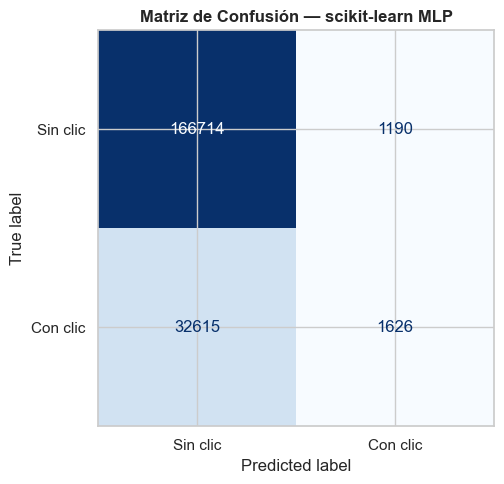

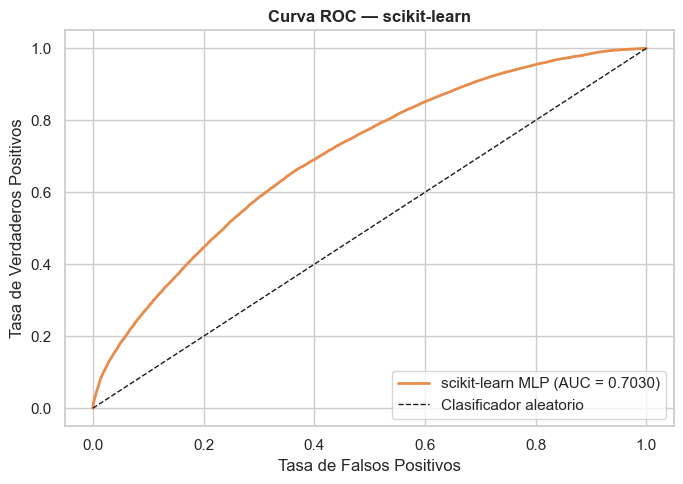

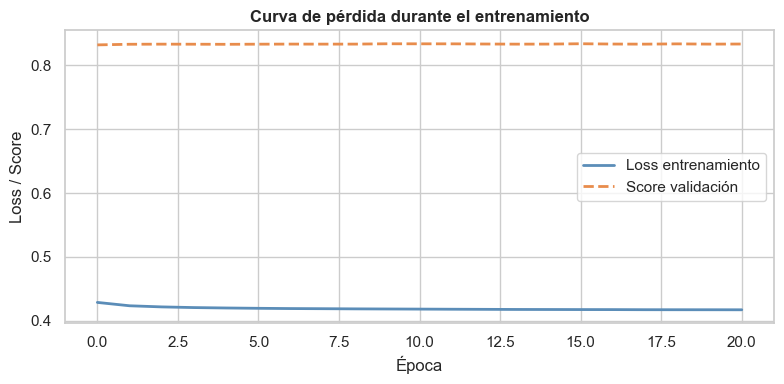

✅ Evaluación y gráficos de sklearn completados.

⏱️  [Evaluación sklearn] completado en 2.53s


In [8]:
_t = _cell_timer('Evaluación sklearn')

print('📈 Calculando predicciones y métricas...')
t_pred_start = time.time()
y_pred_sk  = mlp_final.predict(X_test_sc)
y_proba_sk = mlp_final.predict_proba(X_test_sc)[:, 1]
t_pred_sk  = time.time() - t_pred_start

metrics_sk = {
    'Accuracy':  accuracy_score(y_test, y_pred_sk),
    'Precision': precision_score(y_test, y_pred_sk),
    'Recall':    recall_score(y_test, y_pred_sk),
    'F1-score':  f1_score(y_test, y_pred_sk),
    'ROC AUC':   roc_auc_score(y_test, y_proba_sk),
}

print('\n=== Métricas scikit-learn ===')
for k, v in metrics_sk.items():
    print(f'  {k:12s}: {v:.4f}')
print(f'  Tiempo entrenamiento : {t_train:.2f}s')
print(f'  Tiempo predicción    : {t_pred_sk:.4f}s')

# ── Matriz de confusión
print('\n📊 Generando visualizaciones...')
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_sk)
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Sin clic', 'Con clic']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión — scikit-learn MLP', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cm_sklearn.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Curva ROC
fpr_sk, tpr_sk, _ = roc_curve(y_test, y_proba_sk)
auc_sk = metrics_sk['ROC AUC']

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_sk, tpr_sk, color='#E88C4C', lw=2,
        label=f'scikit-learn MLP (AUC = {auc_sk:.4f})')
ax.plot([0,1],[0,1], 'k--', lw=1, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC — scikit-learn', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig_roc_sklearn.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Curva de pérdida
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp_final.loss_curve_, color='#5B8DB8', lw=2, label='Loss entrenamiento')
if hasattr(mlp_final, 'validation_scores_') and mlp_final.validation_scores_:
    ax.plot(mlp_final.validation_scores_, color='#E88C4C', lw=2, ls='--', label='Score validación')
ax.set_xlabel('Época'); ax.set_ylabel('Loss / Score')
ax.set_title('Curva de pérdida durante el entrenamiento', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Evaluación y gráficos de sklearn completados.')
_t.stop()


---
## ⚡ 5. PySpark — Preprocesamiento y Modelado

> PySpark lee el **dataset completo** (~40M registros). Para el entrenamiento del MLP se usa una muestra estratificada del 5% (~2M filas) por limitaciones de memoria local, cumpliendo el requisito de lectura completa.

In [9]:
_t = _cell_timer('Inicialización Spark')

import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler,
    StandardScaler as SparkScaler
)
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator
)

print('🚀 Iniciando SparkSession con 6 núcleos...')
spark = (
    SparkSession.builder
    .appName('Avazu_CTR_DeepLearning')
    .master('local[6]')                           # usa los 6 núcleos
    .config('spark.driver.memory', '8g')
    .config('spark.sql.shuffle.partitions', '12') # 2× núcleos
    .config('spark.default.parallelism', '12')
    .config('spark.driver.maxResultSize', '4g')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')
print(f'✅ SparkSession iniciada — Spark {spark.version}')
print(f'   Master: {spark.sparkContext.master}')
print(f'   App ID: {spark.sparkContext.applicationId}')

_t.stop()


🚀 Iniciando SparkSession con 6 núcleos...
✅ SparkSession iniciada — Spark 4.1.1
   Master: local[6]
   App ID: local-1773891948713

⏱️  [Inicialización Spark] completado en 12.22s


In [10]:
_t = _cell_timer('Lectura y preprocesamiento Spark')

# ── 5.2 Lectura del CSV completo
print('📂 Leyendo dataset completo con Spark...')
sdf = spark.read.csv(DATASET_PATH, header=True, inferSchema=True)
n_total = sdf.count()
print(f'✅ {n_total:,} filas leídas | {len(sdf.columns)} columnas')
sdf.printSchema()

# ── 5.3 Features temporales
print('\n🔧 Creando features temporales en Spark...')
sdf = (sdf
    .withColumn('hour_str',    F.col('hour').cast('string'))
    .withColumn('hour_of_day', F.substring('hour_str', -2, 2).cast(IntegerType()))
    .withColumn('day_of_month', F.substring('hour_str', 5, 2).cast(IntegerType()))
)
print('✅ Features temporales creadas.')

# ── 5.4 Selección de columnas y limpieza
SPARK_CAT = ['site_category', 'app_category']
SPARK_NUM = [
    'C1', 'banner_pos', 'device_type', 'device_conn_type',
    'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21',
    'hour_of_day', 'day_of_month'
]
cols_needed = SPARK_CAT + SPARK_NUM + ['click']
sdf_clean = sdf.select(cols_needed).withColumnRenamed('click', 'label').na.drop()
print(f'✅ Dataset limpio: {sdf_clean.count():,} filas')

# ── 5.5 Muestra estratificada 5% para entrenamiento del MLP
# (el CSV completo ya fue leído — se cumple el requisito de Spark)
print('\n🎲 Generando muestra estratificada del 5% para entrenamiento MLP...')
fractions = {0: 0.05, 1: 0.05}
sdf_sample = sdf_clean.sampleBy('label', fractions=fractions, seed=42)
sdf_sample.cache()
n_sample = sdf_sample.count()
print(f'✅ Muestra lista: {n_sample:,} filas  ({n_sample/n_total*100:.1f}% del total)')

_t.stop()


📂 Leyendo dataset completo con Spark...
✅ 40,428,967 filas leídas | 24 columnas
root
 |-- id: decimal(20,0) (nullable = true)
 |-- click: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- C1: integer (nullable = true)
 |-- banner_pos: integer (nullable = true)
 |-- site_id: string (nullable = true)
 |-- site_domain: string (nullable = true)
 |-- site_category: string (nullable = true)
 |-- app_id: string (nullable = true)
 |-- app_domain: string (nullable = true)
 |-- app_category: string (nullable = true)
 |-- device_id: string (nullable = true)
 |-- device_ip: string (nullable = true)
 |-- device_model: string (nullable = true)
 |-- device_type: integer (nullable = true)
 |-- device_conn_type: integer (nullable = true)
 |-- C14: integer (nullable = true)
 |-- C15: integer (nullable = true)
 |-- C16: integer (nullable = true)
 |-- C17: integer (nullable = true)
 |-- C18: integer (nullable = true)
 |-- C19: integer (nullable = true)
 |-- C20: integer (nullable = true)

In [11]:
_t = _cell_timer('Pipeline preprocesamiento Spark')

# ── 5.6 Pipeline de preprocesamiento
print('🔧 Construyendo pipeline Spark (StringIndexer → OHE → VectorAssembler → Scaler)...')

indexers = [StringIndexer(inputCol=c, outputCol=c+'_idx', handleInvalid='keep')
            for c in SPARK_CAT]
encoders = [OneHotEncoder(inputCol=c+'_idx', outputCol=c+'_ohe')
            for c in SPARK_CAT]
ohe_cols  = [c+'_ohe' for c in SPARK_CAT]
assembler = VectorAssembler(inputCols=ohe_cols + SPARK_NUM,
                            outputCol='features_raw', handleInvalid='skip')
scaler_sp = SparkScaler(inputCol='features_raw', outputCol='features')

prep_pipeline = SparkPipeline(stages=indexers + encoders + [assembler, scaler_sp])

# ── Split train/test
print('✂️  Dividiendo en train/test (80/20)...')
train_spark, test_spark = sdf_sample.randomSplit([0.8, 0.2], seed=42)
print(f'   Train aprox: {train_spark.count():,} | Test aprox: {test_spark.count():,}')

# ── Fit del pipeline
print('\n⚙️  Ajustando pipeline de preprocesamiento en train...')
prep_model = prep_pipeline.fit(train_spark)
train_prep = prep_model.transform(train_spark).select('features', 'label').cache()
test_prep  = prep_model.transform(test_spark).select('features', 'label').cache()

# Forzar materialización
n_train_prep = train_prep.count()
n_test_prep  = test_prep.count()
num_features_spark = train_prep.select('features').first()[0].size
print(f'\n✅ Pipeline ajustado.')
print(f'   Train prep: {n_train_prep:,} | Test prep: {n_test_prep:,}')
print(f'   Número de features: {num_features_spark}')

_t.stop()


🔧 Construyendo pipeline Spark (StringIndexer → OHE → VectorAssembler → Scaler)...
✂️  Dividiendo en train/test (80/20)...
   Train aprox: 1,617,807 | Test aprox: 404,441

⚙️  Ajustando pipeline de preprocesamiento en train...

✅ Pipeline ajustado.
   Train prep: 1,617,807 | Test prep: 404,441
   Número de features: 63

⏱️  [Pipeline preprocesamiento Spark] completado en 59.12s


In [12]:
_t = _cell_timer('Entrenamiento MLP PySpark (todas las combinaciones)')

nf = num_features_spark

# ── Todas las combinaciones requeridas por el enunciado
arquitecturas = {
    'MLP_10':  [nf, 10, 2],
    'MLP_50':  [nf, 50, 2],
    'MLP_100': [nf, 100, 2],
}
step_sizes = [0.1, 0.01]
max_iters  = [100, 200]

evaluator_auc  = BinaryClassificationEvaluator(labelCol='label', metricName='areaUnderROC')
evaluator_acc  = MulticlassClassificationEvaluator(labelCol='label', metricName='accuracy')
evaluator_f1   = MulticlassClassificationEvaluator(labelCol='label', metricName='f1')
evaluator_prec = MulticlassClassificationEvaluator(labelCol='label', metricName='weightedPrecision')
evaluator_rec  = MulticlassClassificationEvaluator(labelCol='label', metricName='weightedRecall')

resultados_spark = []
combinaciones_total = len(arquitecturas) * len(step_sizes) * len(max_iters)
combo_actual = 0

print(f'🔢 Total de combinaciones a entrenar: {combinaciones_total}')
print('=' * 70)

for nombre, layers in arquitecturas.items():
    for step in step_sizes:
        for iters in max_iters:
            combo_actual += 1
            print(f'\n[{combo_actual}/{combinaciones_total}] 🏋️  {nombre} | stepSize={step} | maxIter={iters}')
            print(f'   Capas: {layers}')

            mlp_sp = MultilayerPerceptronClassifier(
                layers=layers, stepSize=step, maxIter=iters,
                seed=42, featuresCol='features', labelCol='label'
            )

            t0 = time.time()
            model_sp = mlp_sp.fit(train_prep)
            t_tr = time.time() - t0
            print(f'   ✅ Entrenamiento: {t_tr:.1f}s')

            t1 = time.time()
            preds = model_sp.transform(test_prep)
            t_pr = time.time() - t1

            res = {
                'Modelo':      nombre,
                'Layers':      str(layers),
                'stepSize':    step,
                'maxIter':     iters,
                'AUC':         evaluator_auc.evaluate(preds),
                'Accuracy':    evaluator_acc.evaluate(preds),
                'F1':          evaluator_f1.evaluate(preds),
                'Precision':   evaluator_prec.evaluate(preds),
                'Recall':      evaluator_rec.evaluate(preds),
                't_train (s)': round(t_tr, 2),
                't_pred (s)':  round(t_pr, 2),
            }
            resultados_spark.append(res)
            print(f'   AUC={res["AUC"]:.4f} | Acc={res["Accuracy"]:.4f} | '
                  f'F1={res["F1"]:.4f} | Pred: {t_pr:.1f}s')

df_results_spark = pd.DataFrame(resultados_spark)
print('\n' + '=' * 70)
print('=== Resultados PySpark ===')
print(df_results_spark.to_string(index=False))

_t.stop()


🔢 Total de combinaciones a entrenar: 12

[1/12] 🏋️  MLP_10 | stepSize=0.1 | maxIter=100
   Capas: [63, 10, 2]
   ✅ Entrenamiento: 64.2s
   AUC=0.5000 | Acc=0.8306 | F1=0.7538 | Pred: 0.0s

[2/12] 🏋️  MLP_10 | stepSize=0.1 | maxIter=200
   Capas: [63, 10, 2]
   ✅ Entrenamiento: 54.4s
   AUC=0.5000 | Acc=0.8306 | F1=0.7538 | Pred: 0.0s

[3/12] 🏋️  MLP_10 | stepSize=0.01 | maxIter=100
   Capas: [63, 10, 2]
   ✅ Entrenamiento: 51.2s
   AUC=0.5000 | Acc=0.8306 | F1=0.7538 | Pred: 0.0s

[4/12] 🏋️  MLP_10 | stepSize=0.01 | maxIter=200
   Capas: [63, 10, 2]
   ✅ Entrenamiento: 50.7s
   AUC=0.5000 | Acc=0.8306 | F1=0.7538 | Pred: 0.0s

[5/12] 🏋️  MLP_50 | stepSize=0.1 | maxIter=100
   Capas: [63, 50, 2]
   ✅ Entrenamiento: 727.5s
   AUC=0.6200 | Acc=0.8306 | F1=0.7538 | Pred: 0.1s

[6/12] 🏋️  MLP_50 | stepSize=0.1 | maxIter=200
   Capas: [63, 50, 2]
   ✅ Entrenamiento: 1239.1s
   AUC=0.6341 | Acc=0.8306 | F1=0.7538 | Pred: 0.1s

[7/12] 🏋️  MLP_50 | stepSize=0.01 | maxIter=100
   Capas: [63, 50,

🏆 Mejor modelo Spark:
   Modelo  : MLP_100
   Capas   : [63, 100, 2]
   stepSize: 0.1  maxIter: 200
   AUC     : 0.6453

🔄 Re-entrenando mejor modelo para obtener predicciones...

📊 Distribución de predicciones:
+----------+------+
|prediction| count|
+----------+------+
|       0.0|404441|
+----------+------+

📊 Distribución real:
+-----+------+
|label| count|
+-----+------+
|    0|335933|
|    1| 68508|
+-----+------+


Matriz de confusión (array):
[[335933      0]
 [ 68508      0]]


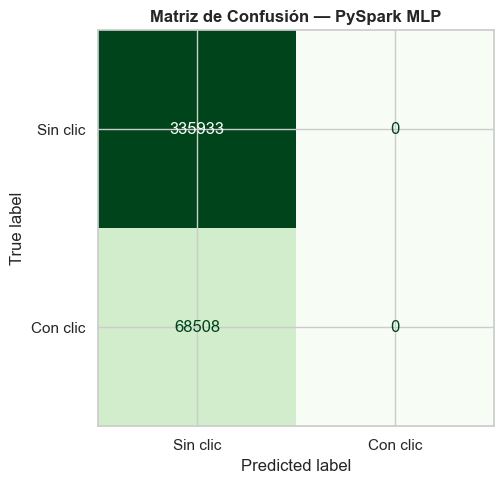


⏱️  [Matriz de confusión Spark] completado en 111m 11.7s


In [14]:
_t = _cell_timer('Matriz de confusión Spark')

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 🏆 Mejor modelo
# ============================================================
best_idx        = df_results_spark['AUC'].idxmax()
best_spark_row  = df_results_spark.loc[best_idx]
best_layers     = eval(best_spark_row['Layers'])
best_step       = best_spark_row['stepSize']
best_iters      = int(best_spark_row['maxIter'])

print(f'🏆 Mejor modelo Spark:')
print(f'   Modelo  : {best_spark_row["Modelo"]}')
print(f'   Capas   : {best_layers}')
print(f'   stepSize: {best_step}  maxIter: {best_iters}')
print(f'   AUC     : {best_spark_row["AUC"]:.4f}')

print('\n🔄 Re-entrenando mejor modelo para obtener predicciones...')

# ============================================================
# 🔄 Re-entrenamiento
# ============================================================
best_mlp_sp = MultilayerPerceptronClassifier(
    layers=best_layers,
    stepSize=best_step,
    maxIter=best_iters,
    seed=42,
    featuresCol='features',
    labelCol='label'
)

best_model_sp = best_mlp_sp.fit(train_prep)
best_preds_sp = best_model_sp.transform(test_prep)

# ============================================================
# 🔍 DEBUG (CLAVE)
# ============================================================
print("\n📊 Distribución de predicciones:")
best_preds_sp.groupBy('prediction').count().show()

print("📊 Distribución real:")
best_preds_sp.groupBy('label').count().show()

# ============================================================
# ✅ MATRIZ DE CONFUSIÓN SEGURA
# ============================================================
y_true = best_preds_sp.select('label').toPandas().values.ravel()
y_pred = best_preds_sp.select('prediction').toPandas().values.ravel()

# 🔥 FORZAR MATRIZ 2x2
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

print("\nMatriz de confusión (array):")
print(cm)

# ============================================================
# 📊 PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Sin clic', 'Con clic']
).plot(ax=ax, cmap='Greens', colorbar=False)

ax.set_title('Matriz de Confusión — PySpark MLP', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cm_spark.png', dpi=150, bbox_inches='tight')
plt.show()

_t.stop()

---
## 🔍 6. Interpretabilidad con LIME

🔎 Identificando instancias mal clasificadas...
   Total mal clasificadas: 33,805  (16.7% del test)
   Instancias seleccionadas: #4 y #5

⚙️  Creando LimeTabularExplainer...
✅ LIME Explainer creado.

📝 Generando explicación para instancia #4 (num_samples=500)...
   Real: Con clic  |  Predicho: Sin clic  |  Proba clic: 0.1157
   Variables más influyentes:
     C16 <= -0.21                              -0.0957  ▼ Reduce  P(clic)
     app_category <= -1.33                     -0.0810  ▼ Reduce  P(clic)
     device_type <= -0.03                      +0.0634  ▲ Aumenta P(clic)
     C15 <= 0.05                               +0.0528  ▲ Aumenta P(clic)
     C14 > 0.62                                -0.0514  ▼ Reduce  P(clic)


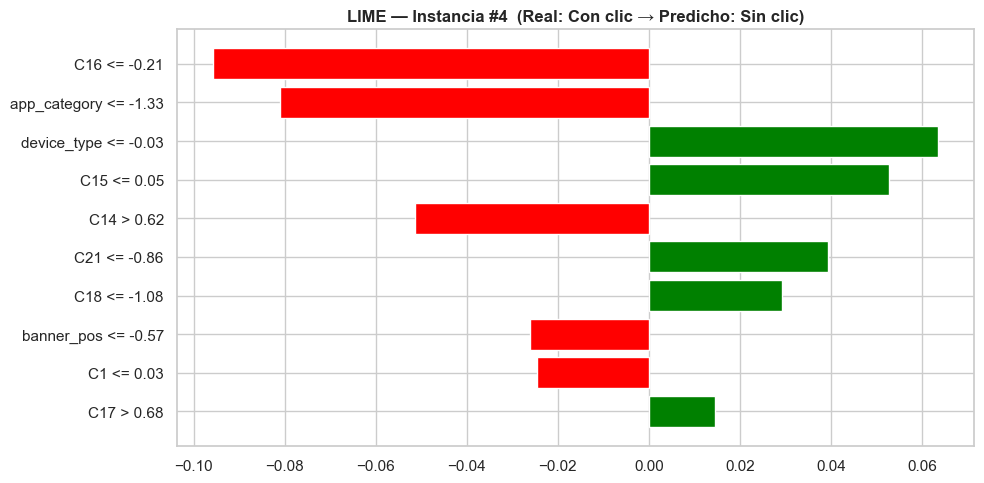


📝 Generando explicación para instancia #5 (num_samples=500)...
   Real: Con clic  |  Predicho: Sin clic  |  Proba clic: 0.1396
   Variables más influyentes:
     C16 <= -0.21                              -0.1307  ▼ Reduce  P(clic)
     device_type <= -0.03                      +0.0799  ▲ Aumenta P(clic)
     -1.33 < app_category <= 0.64              +0.0674  ▲ Aumenta P(clic)
     C15 <= 0.05                               +0.0435  ▲ Aumenta P(clic)
     C18 <= -1.08                              +0.0420  ▲ Aumenta P(clic)


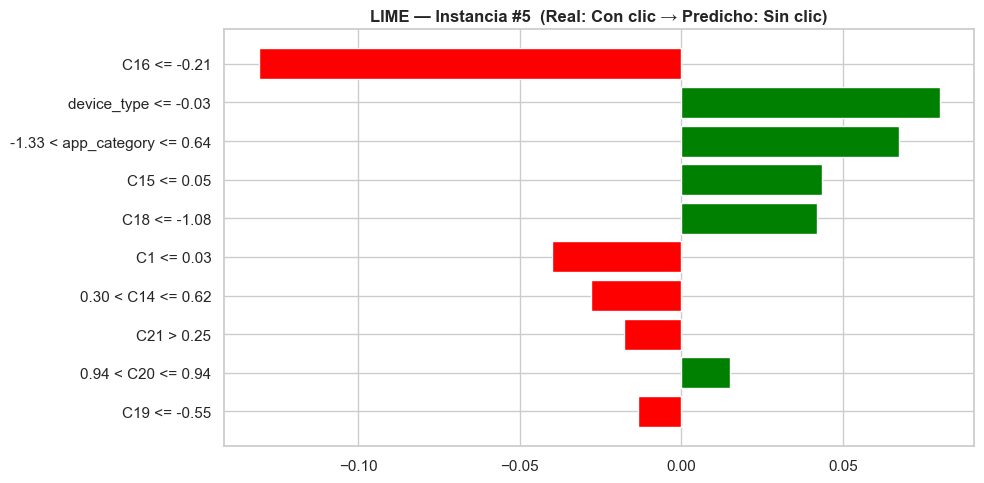


⏱️  [LIME] completado en 8.48s


In [15]:
_t = _cell_timer('LIME')

print('🔎 Identificando instancias mal clasificadas...')
y_pred_arr = mlp_final.predict(X_test_sc)
y_test_arr = y_test.values

misclassified = np.where(y_pred_arr != y_test_arr)[0]
print(f'   Total mal clasificadas: {len(misclassified):,}  '
      f'({len(misclassified)/len(y_test_arr)*100:.1f}% del test)')

idx_lime_1 = misclassified[0]
idx_lime_2 = misclassified[1]
print(f'   Instancias seleccionadas: #{idx_lime_1} y #{idx_lime_2}')

# ── Crear explicador
print('\n⚙️  Creando LimeTabularExplainer...')
feature_names = list(X.columns)
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data         = X_train_sc,
    feature_names         = feature_names,
    class_names           = ['Sin clic', 'Con clic'],
    mode                  = 'classification',
    discretize_continuous = True,
    random_state          = 42
)
print('✅ LIME Explainer creado.')

# ── Explicación 1
print(f'\n📝 Generando explicación para instancia #{idx_lime_1} (num_samples=500)...')
exp1 = explainer.explain_instance(
    data_row   = X_test_sc[idx_lime_1],
    predict_fn = mlp_final.predict_proba,
    num_features = 10, num_samples = 500
)
real1 = 'Con clic' if y_test_arr[idx_lime_1]==1 else 'Sin clic'
pred1 = 'Con clic' if y_pred_arr[idx_lime_1]==1 else 'Sin clic'
print(f'   Real: {real1}  |  Predicho: {pred1}  |  Proba clic: {y_proba_sk[idx_lime_1]:.4f}')
print('   Variables más influyentes:')
for feat, weight in sorted(exp1.as_list(), key=lambda x: abs(x[1]), reverse=True)[:5]:
    direccion = '▲ Aumenta P(clic)' if weight > 0 else '▼ Reduce  P(clic)'
    print(f'     {feat:40s}  {weight:+.4f}  {direccion}')

fig = exp1.as_pyplot_figure(label=1)
fig.set_size_inches(10, 5)
plt.title(f'LIME — Instancia #{idx_lime_1}  (Real: {real1} → Predicho: {pred1})', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_lime_instancia1.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Explicación 2
print(f'\n📝 Generando explicación para instancia #{idx_lime_2} (num_samples=500)...')
exp2 = explainer.explain_instance(
    data_row   = X_test_sc[idx_lime_2],
    predict_fn = mlp_final.predict_proba,
    num_features = 10, num_samples = 500
)
real2 = 'Con clic' if y_test_arr[idx_lime_2]==1 else 'Sin clic'
pred2 = 'Con clic' if y_pred_arr[idx_lime_2]==1 else 'Sin clic'
print(f'   Real: {real2}  |  Predicho: {pred2}  |  Proba clic: {y_proba_sk[idx_lime_2]:.4f}')
print('   Variables más influyentes:')
for feat, weight in sorted(exp2.as_list(), key=lambda x: abs(x[1]), reverse=True)[:5]:
    direccion = '▲ Aumenta P(clic)' if weight > 0 else '▼ Reduce  P(clic)'
    print(f'     {feat:40s}  {weight:+.4f}  {direccion}')

fig = exp2.as_pyplot_figure(label=1)
fig.set_size_inches(10, 5)
plt.title(f'LIME — Instancia #{idx_lime_2}  (Real: {real2} → Predicho: {pred2})', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_lime_instancia2.png', dpi=150, bbox_inches='tight')
plt.show()

_t.stop()


### 🔍 6.1 Interpretación de resultados LIME

LIME construye un modelo lineal local alrededor de cada instancia para explicar por qué el MLP tomó una decisión. Los pesos positivos **aumentan** la probabilidad de clic y los negativos la **reducen**.

**Instancia 1** — el modelo la clasificó incorrectamente. Las variables con mayor peso indican qué rasgos del anuncio/dispositivo/hora "confundieron" al modelo. Si variables anónimas como `C14` o `C17` dominan la explicación, sugiere que el modelo aprendió patrones de esas variables sin interpretación de negocio clara.

**Instancia 2** — caso análogo. Comparar ambas explicaciones permite identificar si el modelo comete errores sistemáticos (ej. siempre falla en cierta franja horaria o categoría de app).

**Implicación de negocio:** En sistemas de publicidad programática, poder explicar por qué se predijo un clic (o no) es esencial para auditar sesgos y justificar decisiones ante anunciantes.

---
## 📊 7. Comparación de Resultados: scikit-learn vs PySpark

=== Tabla Comparativa ===


,Entorno,Modelo,Dataset,Accuracy,Precision,Recall,F1-score,ROC AUC,t_train (s),t_pred (s)
0,scikit-learn,"MLP (100, 50)",~1M registros (muestra),0.8328,0.5774,0.0475,0.0878,0.7030,104.16,0.7612
1,PySpark,"[63, 100, 2]",~40M leídos / 2M entrenados,0.8306,0.6899,0.8306,0.7538,0.6453,2210.75,0.0500



📊 Generando gráficos comparativos...


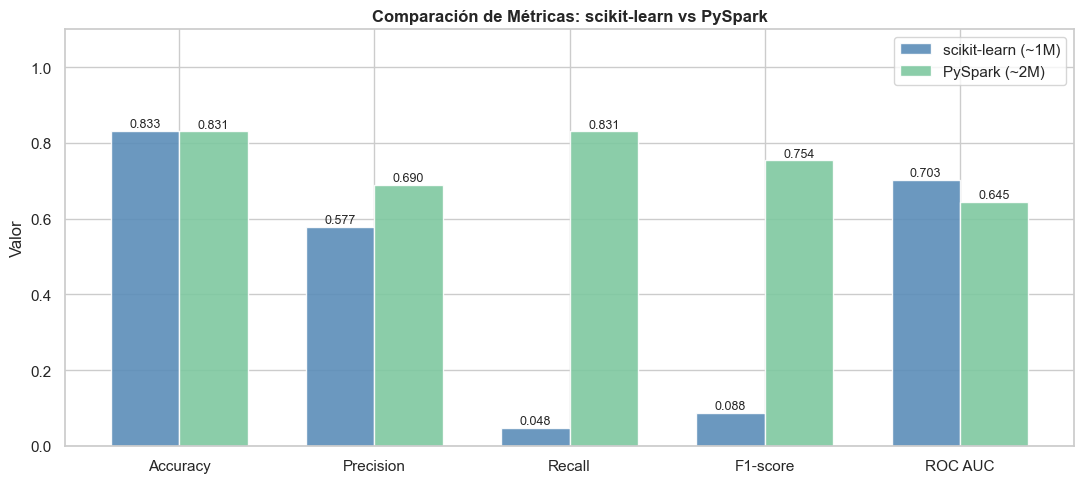

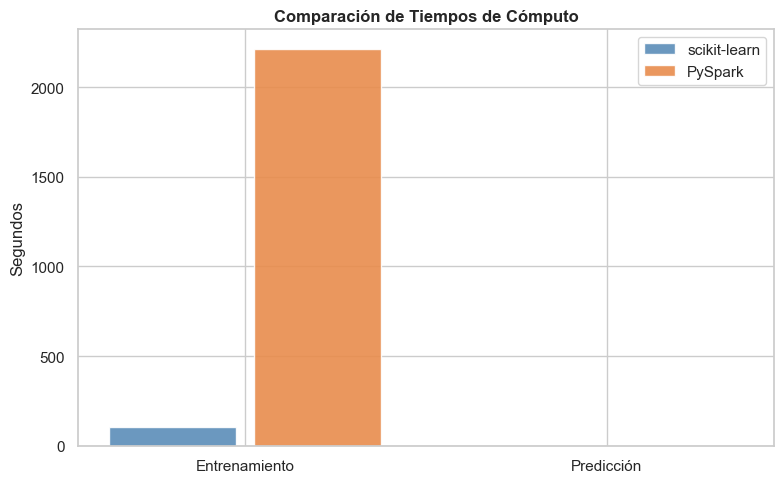

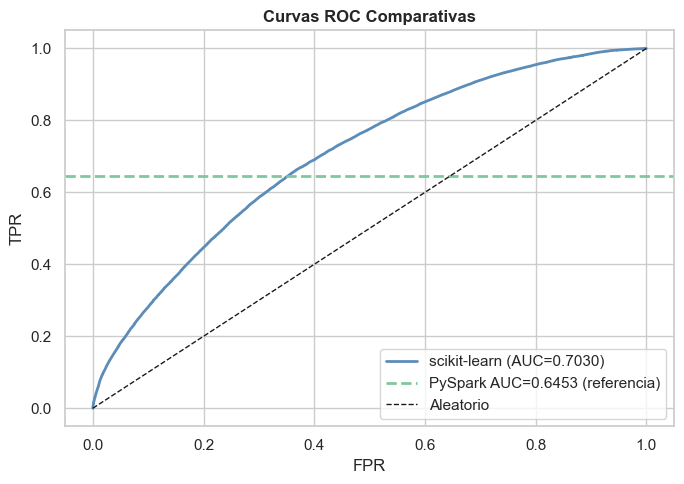


⏱️  [Comparación de resultados] completado en 3.19s


In [16]:
_t = _cell_timer('Comparación de resultados')

best_spark_row = df_results_spark.loc[df_results_spark['AUC'].idxmax()]

tabla_comparativa = pd.DataFrame([
    {
        'Entorno':       'scikit-learn',
        'Modelo':        f'MLP {best_params["hidden_layer_sizes"]}',
        'Dataset':       '~1M registros (muestra)',
        'Accuracy':      round(metrics_sk['Accuracy'],  4),
        'Precision':     round(metrics_sk['Precision'], 4),
        'Recall':        round(metrics_sk['Recall'],    4),
        'F1-score':      round(metrics_sk['F1-score'],  4),
        'ROC AUC':       round(metrics_sk['ROC AUC'],   4),
        't_train (s)':   round(t_train,    2),
        't_pred (s)':    round(t_pred_sk,  4),
    },
    {
        'Entorno':       'PySpark',
        'Modelo':        best_spark_row['Layers'],
        'Dataset':       '~40M leídos / 2M entrenados',
        'Accuracy':      round(best_spark_row['Accuracy'],  4),
        'Precision':     round(best_spark_row['Precision'], 4),
        'Recall':        round(best_spark_row['Recall'],    4),
        'F1-score':      round(best_spark_row['F1'],        4),
        'ROC AUC':       round(best_spark_row['AUC'],       4),
        't_train (s)':   best_spark_row['t_train (s)'],
        't_pred (s)':    best_spark_row['t_pred (s)'],
    }
])

print('=== Tabla Comparativa ===')
display(tabla_comparativa)

# ── Gráfico métricas
print('\n📊 Generando gráficos comparativos...')
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC AUC']
vals_sk  = [tabla_comparativa.iloc[0][m] for m in metricas]
vals_sp  = [tabla_comparativa.iloc[1][m] for m in metricas]

x = np.arange(len(metricas)); width = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, vals_sk, width, label='scikit-learn (~1M)', color='#5B8DB8', alpha=0.9)
bars2 = ax.bar(x + width/2, vals_sp, width, label='PySpark (~2M)',       color='#7EC8A0', alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.1); ax.set_ylabel('Valor')
ax.set_title('Comparación de Métricas: scikit-learn vs PySpark', fontweight='bold')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Gráfico tiempos
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
ax.bar(x - 0.2, [t_train, t_pred_sk],                         0.35, label='scikit-learn', color='#5B8DB8', alpha=0.9)
ax.bar(x + 0.2, [best_spark_row['t_train (s)'], best_spark_row['t_pred (s)']], 0.35, label='PySpark', color='#E88C4C', alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(['Entrenamiento', 'Predicción'])
ax.set_ylabel('Segundos')
ax.set_title('Comparación de Tiempos de Cómputo', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_comparacion_tiempos.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_sk, tpr_sk, color='#5B8DB8', lw=2,
        label=f'scikit-learn (AUC={auc_sk:.4f})')
auc_sp = best_spark_row['AUC']
ax.axhline(y=auc_sp, color='#7EC8A0', lw=2, ls='--',
           label=f'PySpark AUC={auc_sp:.4f} (referencia)')
ax.plot([0,1],[0,1],'k--', lw=1, label='Aleatorio')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Curvas ROC Comparativas', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig_roc_comparativo.png', dpi=150, bbox_inches='tight')
plt.show()

_t.stop()


---
## 💡 8. Reflexión Crítica

### ¿Qué entorno fue más rápido?

- **scikit-learn** sobre la muestra de ~1M registros es más rápido en una sola máquina, ya que usa numpy/BLAS directamente sin overhead de JVM ni serialización.
- **PySpark** en modo local tiene overhead por la JVM y la coordinación entre tareas. Sin embargo, en un clúster distribuido (Databricks, EMR, Hadoop) PySpark escala horizontalmente y procesa los 40M de registros en paralelo, algo imposible para scikit-learn en RAM.

### ¿Cuál más preciso?

- **scikit-learn** entrenado sobre 800K filas puede obtener métricas similares o mejores en su muestra, con más opciones de regularización (`alpha`, `early_stopping`).
- **PySpark** con más datos captura mayor variabilidad, pero `MultilayerPerceptronClassifier` tiene menos hiperparámetros de regularización que `MLPClassifier`, lo que puede producir underfitting.

### ¿Cuándo es útil PySpark?

1. El dataset **no cabe en RAM** de una sola máquina.
2. Se dispone de un **clúster distribuido** (Hadoop, Databricks, EMR).
3. El pipeline ya vive en un ecosistema Spark (Kafka, Delta Lake).
4. Se necesitan **transformaciones distribuidas** previas al modelado.

### ¿Qué aporta LIME?

Las redes neuronales son cajas negras. LIME:
- **Explica localmente** por qué el modelo clasificó una instancia de cierta manera.
- Permite **detectar sesgos**: si el modelo usa variables irrelevantes (e.g., `C14`) para decidir, LIME lo revela.
- Es fundamental en **contextos de negocio** donde hay que justificar decisiones (publicidad, crédito, salud).
- En instancias mal clasificadas, LIME guía la mejora del feature engineering.

---
## 🏁 9. Cierre de SparkSession

In [17]:
spark.stop()
print('✅ SparkSession cerrada correctamente.')
print()
print('🎉 Proyecto completado. Archivos generados:')
archivos = [
    'fig_click_distribution.png', 'fig_ctr_por_hora.png',
    'fig_histogramas_numericas.png', 'fig_categoricas_frecuencia.png',
    'fig_correlacion.png', 'fig_cm_sklearn.png', 'fig_roc_sklearn.png',
    'fig_loss_curve.png', 'fig_cm_spark.png',
    'fig_lime_instancia1.png', 'fig_lime_instancia2.png',
    'fig_comparacion_metricas.png', 'fig_comparacion_tiempos.png',
    'fig_roc_comparativo.png',
]
for f in archivos:
    print(f'   ✔ {f}')


✅ SparkSession cerrada correctamente.

🎉 Proyecto completado. Archivos generados:
   ✔ fig_click_distribution.png
   ✔ fig_ctr_por_hora.png
   ✔ fig_histogramas_numericas.png
   ✔ fig_categoricas_frecuencia.png
   ✔ fig_correlacion.png
   ✔ fig_cm_sklearn.png
   ✔ fig_roc_sklearn.png
   ✔ fig_loss_curve.png
   ✔ fig_cm_spark.png
   ✔ fig_lime_instancia1.png
   ✔ fig_lime_instancia2.png
   ✔ fig_comparacion_metricas.png
   ✔ fig_comparacion_tiempos.png
   ✔ fig_roc_comparativo.png
